In [1]:
!pip install -U diffusers transformers accelerate fastapi uvicorn pyngrok python-multipart -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.7/144.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.45.1 which is incompatible.
opentelemetry-semantic-conventions 0.63b1 requires opentelemetry-api==1.42.1, but you have opentelemetry-api 1.45.1 which is incompatible.
opentelemetry-sdk 1.42.1 requires opentelemetry-api==1.42.1, but you have opentelemetry-api 1.45.1 which is incompatible.


STEP 1-torchaudio fix + load depth model + ControlNet + SD (all three, since generation needs all of them together):

In [5]:
import sys, types, importlib.machinery

# Mock torchaudio
fake_torchaudio = types.ModuleType("torchaudio")
fake_torchaudio.__spec__ = importlib.machinery.ModuleSpec("torchaudio", loader=None)
sys.modules["torchaudio"] = fake_torchaudio

# Completely mock torchao and torchao.quantization to avoid import issues
fake_torchao = types.ModuleType("torchao")
fake_torchao.__spec__ = importlib.machinery.ModuleSpec("torchao", loader=None)
sys.modules["torchao"] = fake_torchao

fake_torchao_q = types.ModuleType("torchao.quantization")
fake_torchao_q.__spec__ = importlib.machinery.ModuleSpec("torchao.quantization", loader=None)
# Add mock attributes expected by diffusers
fake_torchao_q.FqnToConfig = None
fake_torchao_q.quantize_ = None
sys.modules["torchao.quantization"] = fake_torchao_q

import torch
from transformers import pipeline as hf_pipeline
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel

depth_estimator = hf_pipeline(task="depth-estimation", model="Intel/dpt-hybrid-midas", device=0)

controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-depth", torch_dtype=torch.float16)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16
).to("cuda")

print("Depth + ControlNet + SD loaded")

config.json:   0%|          | 0.00/9.88k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  490MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/414 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/382 [00:00<?, ?B/s]

...

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Depth + ControlNet + SD loaded


STEP 2-FastAPI app + /generate endpoint:

In [6]:
from fastapi import FastAPI, UploadFile, File, Form
from PIL import Image
from io import BytesIO
import base64
import traceback

gen_app = FastAPI()

@gen_app.get("/health")
def health():
    print("Received /health request") # Added print statement
    return {"status": "ok"}

@gen_app.post("/generate")
async def generate_endpoint(
    file: UploadFile = File(...),
    generation_prompt: str = Form(...)
):
    try:
        image_bytes = await file.read()
        room_image = Image.open(BytesIO(image_bytes)).convert("RGB").resize((512, 512))

        depth_result = depth_estimator(room_image)
        depth_map = depth_result["depth"].resize((512, 512))

        result_image = pipe(
            prompt=generation_prompt,
            image=depth_map,
            guidance_scale=7.5,
            num_inference_steps=30,
            controlnet_conditioning_scale=1.0
        ).images[0]

        buffered = BytesIO()
        result_image.save(buffered, format="PNG")

        return {
            "status": "success",
            "image_base64": base64.b64encode(
                buffered.getvalue()
            ).decode()
        }

    except Exception as e:
        print(traceback.format_exc())
        return {
            "status": "error",
            "error_type": type(e).__name__,
            "error_message": str(e)
        }

In [7]:
import nest_asyncio
nest_asyncio.apply()

from pyngrok import ngrok
import uvicorn
import asyncio

ngrok.kill()
# Kill any processes already using port 8002
!kill -9 $(lsof -t -i:8002) 2>/dev/null

# Add your ngrok authentication token here
# You can get one from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3JldqOQ6KsdA5jhdpAZmAPd7LTO_3fVXobxDR8KRz9oPHJJnC") # REPLACE "YOUR_AUTH_TOKEN" WITH YOUR ACTUAL TOKEN

public_url = ngrok.connect(8002)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://babied-subpanel-geography.ngrok-free.dev" -> "http://localhost:8002"


STEP 3- run server + ngrok tunnel:




In [8]:
from pyngrok import ngrok
import nest_asyncio
import uvicorn
import asyncio
import threading
import time

nest_asyncio.apply()

ngrok.set_auth_token("3JldqOQ6KsdA5jhdpAZmAPd7LTO_3fVXobxDR8KRz9oPHJJnC")

# Ensure the port is free before starting the server
!kill -9 $(lsof -t -i:8002) 2>/dev/null
ngrok.kill() # Kill ngrok tunnels if any

def run_uvicorn_server(app_instance):
    """Function to run uvicorn server in its own event loop within a thread."""
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    config = uvicorn.Config(app_instance, host="0.0.0.0", port=8002, log_level="info")
    server = uvicorn.Server(config)
    print("INFO: Uvicorn thread started, attempting to run server.")
    loop.run_until_complete(server.serve())
    print("INFO: Uvicorn server stopped.")

# Start uvicorn in a separate thread, passing gen_app as an argument
server_thread = threading.Thread(target=run_uvicorn_server, args=(gen_app,))
server_thread.daemon = True
try:
    server_thread.start()
    print("INFO: Server thread started successfully.")
except Exception as e:
    print(f"ERROR: Failed to start server thread: {e}")

# Give the server a moment to start up and bind to the port
time.sleep(5)

public_url = ngrok.connect(8002)
print("Public URL:", public_url)

INFO: Server thread started successfully.


INFO:     Started server process [2142]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8002 (Press CTRL+C to quit)


INFO: Uvicorn thread started, attempting to run server.


/usr/local/lib/python3.13/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'ControlNetModel' object attribute is deprecated. Please access '__iter__' over 'ControlNetModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.13/dist-packages/diffusers/configuration_utils.py:172: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionControlNetPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionControlNetPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Public URL: NgrokTunnel: "https://babied-subpanel-geography.ngrok-free.dev" -> "http://localhost:8002"


In [9]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [10]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [11]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/ai_interior_design")

JOBS_DIR = BASE / "generation_jobs"
OUTPUT_DIR = BASE / "generated"

print("Jobs folder:", JOBS_DIR)
print("Output folder:", OUTPUT_DIR)

print("Jobs exists:", JOBS_DIR.exists())
print("Output exists:", OUTPUT_DIR.exists())

Jobs folder: /content/drive/MyDrive/ai_interior_design/generation_jobs
Output folder: /content/drive/MyDrive/ai_interior_design/generated
Jobs exists: True
Output exists: True


In [12]:
from pathlib import Path
import json
from PIL import Image

job_id = "job_001"

job_dir = JOBS_DIR / job_id
job_dir.mkdir(parents=True, exist_ok=True)

job = {
    "job_id": job_id,
    "generation_prompt": """
Redesign the uploaded bedroom in a modern minimalist style room.
Preserve the existing room architecture, walls, doors, windows,
use what do u think in this room that look good and minimalist and cool and want a bed sidetable short lamps and dressing tab;e colors of our choiuce
""",
    "status": "queued"
}

with open(job_dir / "job.json", "w") as f:
    json.dump(job, f, indent=2)

print("Created:", job_dir / "job.json")

Created: /content/drive/MyDrive/ai_interior_design/generation_jobs/job_001/job.json


In [15]:
import shutil

shutil.copy(
    "/content/room.jpg",
    job_dir / "room.png"
)

print("Image copied:", job_dir / "room.png")

Image copied: /content/drive/MyDrive/ai_interior_design/generation_jobs/job_001/room.png


In [16]:
import json
from pathlib import Path
from PIL import Image

job_id = "job_001"

job_dir = JOBS_DIR / job_id
output_dir = OUTPUT_DIR / job_id
output_dir.mkdir(parents=True, exist_ok=True)

# Load job
with open(job_dir / "job.json", "r") as f:
    job = json.load(f)

# Load room image
room_image = Image.open(
    job_dir / "room.png"
).convert("RGB").resize((512, 512))

print("Job:", job["job_id"])
print("Prompt:", job["generation_prompt"])
print("Image:", room_image.size)

Job: job_001
Prompt: 
Redesign the uploaded bedroom in a modern minimalist style room.
Preserve the existing room architecture, walls, doors, windows,
use what do u think in this room that look good and minimalist and cool and want a bed sidetable short lamps and dressing tab;e colors of our choiuce

Image: (512, 512)


In [17]:
depth_result = depth_estimator(room_image)

depth_map = depth_result["depth"].resize((512, 512))

result_image = pipe(
    prompt=job["generation_prompt"],
    image=depth_map,
    guidance_scale=7.5,
    num_inference_steps=30,
    controlnet_conditioning_scale=1.0
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

In [18]:
result_path = output_dir / "result.png"

result_image.save(result_path)

print("Generated image saved to:")
print(result_path)

Generated image saved to:
/content/drive/MyDrive/ai_interior_design/generated/job_001/result.png


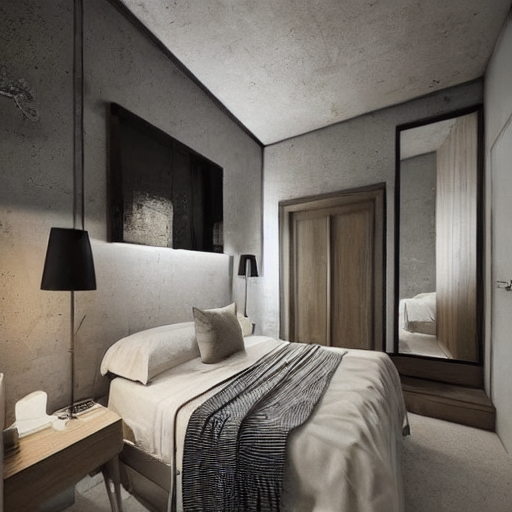

In [19]:
from IPython.display import display

display(result_image)

In [20]:
import json
from pathlib import Path

def find_next_job():
    for job_dir in sorted(JOBS_DIR.iterdir()):

        if not job_dir.is_dir():
            continue

        job_file = job_dir / "job.json"
        room_file = job_dir / "room.png"

        output_dir = OUTPUT_DIR / job_dir.name
        result_file = output_dir / "result.png"

        if not job_file.exists():
            continue

        if not room_file.exists():
            continue

        if result_file.exists():
            continue

        with open(job_file, "r") as f:
            job = json.load(f)

        if job.get("status") == "queued":
            return job_dir, job

    return None, None


job_dir, job = find_next_job()

print("Job directory:", job_dir)
print("Job:", job)

Job directory: None
Job: None


This takes the queued job → runs Depth + ControlNet + Diffusion → saves result.png → marks the job completed.

In [21]:
import json
from pathlib import Path
from PIL import Image

# --------------------------------------------------
# Check that a job was found
# --------------------------------------------------

if job_dir is None or job is None:
    print("No queued jobs found.")
else:

    job_id = job["job_id"]

    print(f"Processing: {job_id}")

    # --------------------------------------------------
    # Mark job as processing
    # --------------------------------------------------

    job["status"] = "processing"

    with open(job_dir / "job.json", "w") as f:
        json.dump(job, f, indent=2)

    # --------------------------------------------------
    # Prepare output directory
    # --------------------------------------------------

    output_dir = OUTPUT_DIR / job_id
    output_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # Load room image
    # --------------------------------------------------

    room_image = Image.open(
        job_dir / "room.png"
    ).convert("RGB").resize((512, 512))

    print("Room image loaded.")

    # --------------------------------------------------
    # Depth estimation
    # --------------------------------------------------

    print("Running depth estimation...")

    depth_result = depth_estimator(room_image)

    depth_map = depth_result["depth"].resize((512, 512))

    print("Depth estimation completed.")

    # --------------------------------------------------
    # ControlNet + Diffusion
    # --------------------------------------------------

    print("Running image generation...")

    result_image = pipe(
        prompt=job["generation_prompt"],
        image=depth_map,
        guidance_scale=7.5,
        num_inference_steps=30,
        controlnet_conditioning_scale=1.0
    ).images[0]

    # --------------------------------------------------
    # Save result
    # --------------------------------------------------

    result_path = output_dir / "result.png"

    result_image.save(result_path)

    print(f"Generated image saved to:")
    print(result_path)

    # --------------------------------------------------
    # Mark job as completed
    # --------------------------------------------------

    job["status"] = "completed"

    with open(job_dir / "job.json", "w") as f:
        json.dump(job, f, indent=2)

    print(f"Job {job_id} completed successfully!")

No queued jobs found.


In [ ]:
job_dir, job = find_next_job()

print("Job directory:", job_dir)
print("Job:", job)

In [ ]:
from pathlib import Path

print("JOBS_DIR:", JOBS_DIR)
print("Exists:", JOBS_DIR.exists())

print("\nJobs found:")
for p in JOBS_DIR.iterdir():
    print(p.name)

In [ ]:
import json

job_id = "job_3d27a447"
job_dir = JOBS_DIR / job_id

print("Job directory:", job_dir)
print("Directory exists:", job_dir.exists())

print("\nFiles:")
for p in job_dir.iterdir():
    print("-", p.name)

print("\nJob JSON:")

with open(job_dir / "job.json", "r") as f:
    job = json.load(f)

print(job)

print("\nRoom image exists:", (job_dir / "room.png").exists())

output_dir = OUTPUT_DIR / job_id
result_file = output_dir / "result.png"

print("Result already exists:", result_file.exists())

In [22]:
import json

old_job_dir = JOBS_DIR / "job_3d27a447"

with open(old_job_dir / "job.json", "r") as f:
    old_job = json.load(f)

old_job["status"] = "completed"

with open(old_job_dir / "job.json", "w") as f:
    json.dump(old_job, f, indent=2)

print("Marked job_3d27a447 as completed.")

Marked job_3d27a447 as completed.


In [23]:
job_dir, job = find_next_job()

print("Job directory:", job_dir)
print("Job:", job)

Job directory: None
Job: None


In [24]:
if job_dir is None or job is None:
    print("No queued jobs found.")
else:
    job_id = job["job_id"]

    print(f"Processing: {job_id}")

    # Mark processing
    job["status"] = "processing"

    with open(job_dir / "job.json", "w") as f:
        json.dump(job, f, indent=2)

    # Output folder
    output_dir = OUTPUT_DIR / job_id
    output_dir.mkdir(parents=True, exist_ok=True)

    # Load room
    room_image = Image.open(
        job_dir / "room.png"
    ).convert("RGB").resize((512, 512))

    print("Room image loaded.")

    # Depth
    print("Running depth estimation...")

    depth_result = depth_estimator(room_image)
    depth_map = depth_result["depth"].resize((512, 512))

    print("Depth estimation completed.")

    # Generation
    print("Running image generation...")

    result_image = pipe(
        prompt=job["generation_prompt"],
        image=depth_map,
        guidance_scale=7.5,
        num_inference_steps=30,
        controlnet_conditioning_scale=1.0
    ).images[0]

    # Save
    result_path = output_dir / "result.png"
    result_image.save(result_path)

    # Completed
    job["status"] = "completed"

    with open(job_dir / "job.json", "w") as f:
        json.dump(job, f, indent=2)

    print(f"Generated image saved to: {result_path}")
    print(f"Job {job_id} completed successfully!")

No queued jobs found.


In [25]:
import time
import json
from pathlib import Path

while True:
    try:
        job_dir, job = find_next_job()

        if job_dir is None:
            print("No queued jobs. Checking again in 5 seconds...")
            time.sleep(5)
            continue

        job_id = job["job_id"]

        print(f"\n{'='*50}")
        print(f"Processing job: {job_id}")
        print(f"{'='*50}")

        # Mark as processing
        job["status"] = "processing"

        with open(job_dir / "job.json", "w") as f:
            json.dump(job, f, indent=2)

        output_dir = OUTPUT_DIR / job_id
        output_dir.mkdir(parents=True, exist_ok=True)

        # Load room
        room_image = Image.open(
            job_dir / "room.png"
        ).convert("RGB").resize((512, 512))

        print("Room image loaded.")

        # Depth
        print("Running depth estimation...")

        depth_result = depth_estimator(room_image)
        depth_map = depth_result["depth"].resize((512, 512))

        print("Depth estimation completed.")

        # Generation
        print("Running image generation...")

        result_image = pipe(
            prompt=job["generation_prompt"],
            image=depth_map,
            guidance_scale=7.5,
            num_inference_steps=30,
            controlnet_conditioning_scale=1.0
        ).images[0]

        # Save result
        result_path = output_dir / "result.png"
        result_image.save(result_path)

        # Mark completed
        job["status"] = "completed"

        with open(job_dir / "job.json", "w") as f:
            json.dump(job, f, indent=2)

        print(f"✅ Job completed: {job_id}")
        print(f"✅ Result: {result_path}")

    except Exception as e:
        print(f"❌ Worker error: {e}")

        if job_dir is not None:
            try:
                job["status"] = "failed"
                job["error"] = str(e)

                with open(job_dir / "job.json", "w") as f:
                    json.dump(job, f, indent=2)

            except Exception:
                pass

        time.sleep(5)

No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued job

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (87 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['wood floors and soft natural lighting coming from a nearby window .']


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Job completed: job_ac23ad0b
✅ Result: /content/drive/MyDrive/ai_interior_design/generated/job_ac23ad0b/result.png
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 seconds...
No queued jobs. Checking again in 5 se

KeyboardInterrupt: 

In [26]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/ai_interior_design"):
    dirs[:] = [d for d in dirs if d not in ["generated", "generation_jobs"]]
    for file in files:
        if file.endswith(".py"):
            print(os.path.join(root, file))

In [28]:

import os

# Check whether Google Drive is mounted
print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))

# Find Python files in your project folder
project_path = "/content/drive/MyDrive/ai_interior_design"

if os.path.exists(project_path):
    for root, dirs, files in os.walk(project_path):
        dirs[:] = [d for d in dirs if d not in ["generated", "generation_jobs"]]
        for name in files:
            if name.endswith(".py"):
                print(os.path.join(root, name))
else:
    print("Project folder not found. Check the Drive mount and folder name.")

Drive mounted: True


In [30]:

import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    dirs[:] = [d for d in dirs if d not in [
        ".cache", "node_modules", "generated", "generation_jobs"
    ]]
    for name in files:
        if name.endswith(".py") and any(
            word in name.lower()
            for word in ["generat", "worker", "design", "depth", "controlnet"]
        ):
            print(os.path.join(root, name))

In [31]:

from google.colab import files
import nbformat

# Export the current notebook's code cells
notebook_path = "/content/generation_worker.ipynb"

print("First download your notebook using File → Download → Download .ipynb")

First download your notebook using File → Download → Download .ipynb
